<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/SamuBenjU4Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm

#Unit 4 Project
I am making a hierarchical model to model the 3 Points that are made by the player positions by using the data set that Mr.Arrendando has given us. This data set contains a total 573 players.

Before we go on with the project, I will give you context about this project. There are 5 positions in every team, a Point Guard, Power Forward, Center, Shooting Guard, and Small Forward. Each positions have different responsibilites, like centers are important for defending the rim and getting rebounds, point guards run the game and generally have lots of assists. Using a hierarchical model will help us the variance that is shown.

Guide for the positions:

C: Center

PF: Power Forward

SF: Small Forward

PG: Point Guard

SG: Shooting Guard

In [ ]:
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/basketball2324.csv"

data = pd.read_csv(url,dtype={'Pos':'category'})


data = data[['Player', 'Pos', '3P', '3PA', '3P%','FT']]
data

,Player,Pos,3P,3PA,3P%,FT
0,Precious Achiuwa,PF-C,26,97,0.268,69
1,Bam Adebayo,C,15,42,0.357,292
2,Ochai Agbaji,SG,62,211,0.294,37
3,Santi Aldama,PF,106,304,0.349,54
4,Nickeil Alexander-Walker,SG,131,335,0.391,52
...,...,...,...,...,...,...
567,Thaddeus Young,PF,1,7,0.143,6
568,Trae Young,PG,175,469,0.373,348
569,Omer Yurtseven,C,5,24,0.208,19
570,Cody Zeller,C,1,3,0.333,23


In [ ]:

pos_idx = data.Pos.cat.codes.values


pos_codes = data.Pos.cat.categories


bask_coords = {"pos": pos_codes}


This makes the basketball positions into mumerical values. This makes it easier for us to use these positions in models. It maps each position to a unique integer label, then stores the string-to-integer mappings in a dictionary that enables PyMC to efficiently handle and interpret position data in Bayesian analyses.

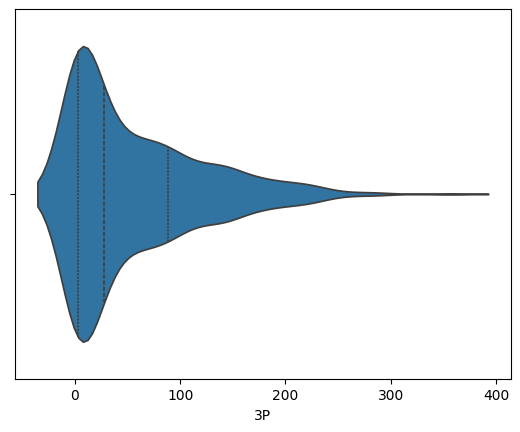

In [ ]:
# visualizing data
# Assuming data is a DataFrame and '3P' is a column in it:
sns.violinplot(data=data, x='3P', inner='quart')

# Show the plot
plt.show()

This is a skew normal model that hasn'y been split by the position yet. It ran with some divergences. The posterior predictive check showed a poor fit, so I think I should use a different model like a exponential model.

In [ ]:
with pm.Model(coords = bask_coords) as bask_model:
    #the hyperpriors
    μ_mu = pm.Normal('μ_mu', mu = 0, sigma = 300)
    μ_sd = pm.HalfNormal('μ_sd', sigma = 30)
    #these are the priors
    μ = pm.Normal('μ', mu = μ_mu, sigma = μ_sd)
    σ = pm.HalfNormal('σ', sigma = 10)
    α = pm.Exponential('α', lam = 5)
    #making it skewnormal
    pm.SkewNormal('3P', mu=μ, sigma=σ, alpha=α, observed=data['3P'].values)  # Correctly reference the '3P' column as a NumPy array

    # Sampling
    idata_bask = pm.sample(target_accept=0.95)

Output()

Output()

ERROR:pymc.stats.convergence:There were 269 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Output()

(0.0, 1100.0)

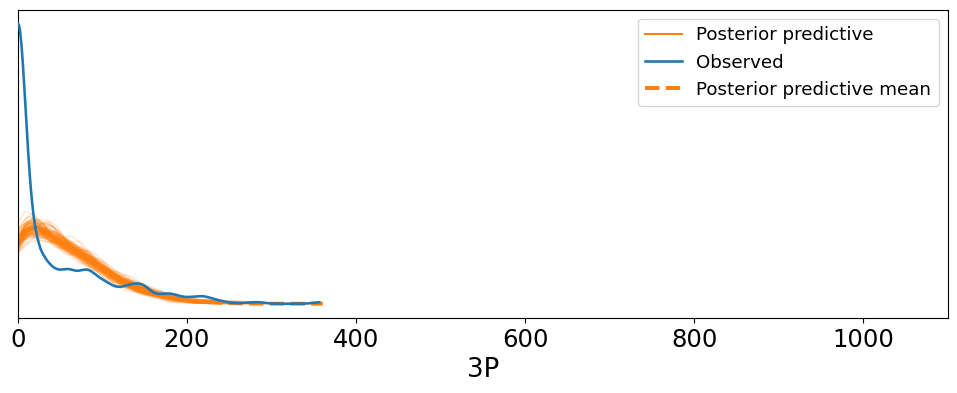

In [ ]:
pm.sample_posterior_predictive(idata_bask, model=bask_model, extend_inferencedata=True)
ax = az.plot_ppc(idata_bask, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])
ax.set_xlim(0, 1100)

This is a skew normal model, the observed data is decent with the posterior predictive. But the exponential model works better with this.

In [ ]:
with pm.Model(coords = bask_coords) as bask_model:
    #hyperpriors
    a = pm.Gamma('a', alpha = 1, beta = 1)
    b = pm.Gamma('b', alpha = 1, beta = 1)

    #priors
    λ = pm.Gamma('λ', alpha = a, beta = b)

    #exponential
    threeP = pm.Exponential('3P', lam = λ, observed = data['3P'].values())

    idata_bask = pm.sample(target_accept = 0.95)

Output()

Output()

Output()

(0.0, 1100.0)

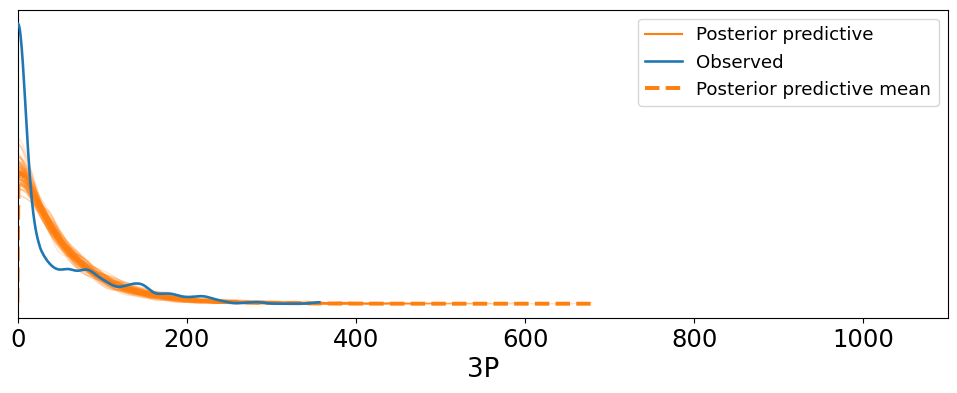

In [ ]:
pm.sample_posterior_predictive(idata_bask, model=bask_model, extend_inferencedata=True)
ax = az.plot_ppc(idata_bask, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])
ax.set_xlim(0, 1100)

As you can see, the exponential model has a way better fit with the posterior predictive than the skew normal model. Since I found this i seperated the posterior by player position, this allows me to use different priors for each position. This will show the amount of 3 pointers made by each position. But all positions will have common hyperpriors and this model will have 0 divergences.


#Analysis
When I generate the trace plots for the parameters of the inference data objects, I adjusted the x-axis of the λ plots to make it easier to interpret. These trace plots can be seen below for the exponential model separated by position. In the λ plot, you can see that some positions have peaks at the end of the plot while others have much lower peaks or have flat spreads.


In [ ]:
with pm.Model(coords = bask_coords) as bask_model:
    #hyperpriors
    a = pm.Gamma('a', alpha = 1, beta = 1)
    b = pm.Gamma('b', alpha = 1, beta = 1)

    #priors
    λ = pm.Gamma('λ', alpha = a, beta = b, dims = "pos")

    #exponetial
    _ = pm.Exponential('3P', lam = λ[pos_idx], observed = data['3P'].values)


    idata_bask = pm.sample(target_accept = 0.95)

Output()

Output()

(0.0, 0.015)

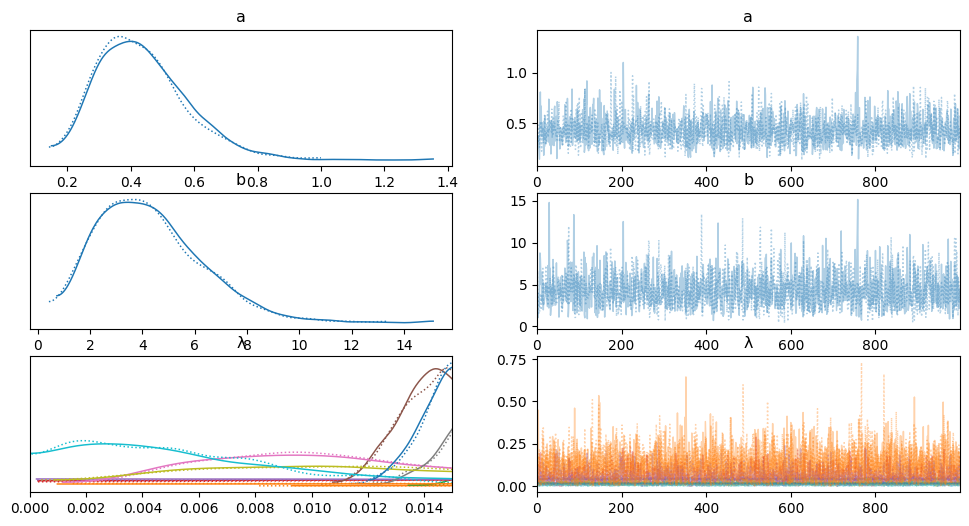

In [ ]:
#az.plot_trace(idata_bask) but limiting the graph of the λ so it is easier to read
az.plot_trace(idata_bask)[2,0].set_xlim([0, .015])

In [ ]:
az.rhat(idata_bask) #we want it to be between 1 and 1.001

<xarray.Dataset> Size: 352B
Dimensions:  (pos: 12)
Coordinates:
  * pos      (pos) <U5 240B 'C' 'C-PF' 'PF' 'PF-C' ... 'SF-SG' 'SG' 'SG-PG'
Data variables:
    a        float64 8B 1.001
    b        float64 8B 1.001
    λ        (pos) float64 96B 1.001 1.004 0.9999 1.001 ... 1.0 1.0 0.9996 1.001

Here's the forest plot of the λ by position. The ridge plot style provides an overlapping visualization of distributions, making it easy to compare uncertainty and spread across groups or categories.

array([<Axes: >], dtype=object)

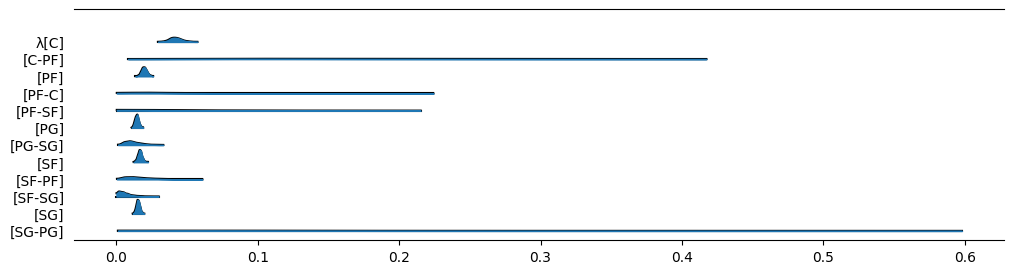

In [ ]:
az.plot_forest(idata_bask, var_names=['λ'], combined=True, figsize=(12, 3), kind = 'ridgeplot', hdi_prob=0.998)

This section calculates the mean values of the parameter λ from the posterior distribution and computes their reciprocals and, puts them in an array.

In [ ]:
#retrieving the array of means

posterior = idata_bask.posterior
lambda_variable = posterior['λ']
mean_lambda = lambda_variable.mean(dim=['chain', 'draw'])
mean_array = mean_lambda.values


#creating the array of reciprocals

reciprocal_array = []
for value in mean_array:
    reciprocal = 1 / value
    reciprocal_array.append(reciprocal)

#print (reciprocal_array)

# go through each of the positions and print it next to the 1/lamda
# print(pos_codes)
for i in range(len(pos_codes)):
    position = pos_codes[i]
    reciprocal = reciprocal_array[i]
    print(f'{position}: {reciprocal}')

C: 23.814711467238975
C-PF: 7.294212891782806
PF: 50.7652706478261
PF-C: 21.97801636025295
PF-SF: 24.096880728465635
PG: 68.85472874930474
PG-SG: 87.28872899676509
SF: 59.880738035178965
SF-PF: 64.27857800271288
SF-SG: 156.01542050594327
SG: 65.0402221217968
SG-PG: 9.655537253964278


<BarContainer object of 12 artists>

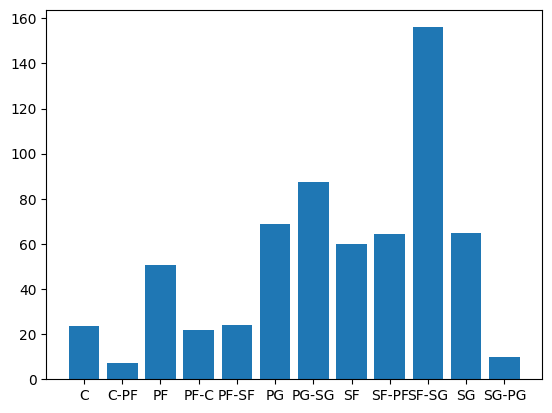

In [ ]:
plt.bar(pos_codes, reciprocal_array)

#Conclusion
This bar graph illustrates the number of 3-pointers made by basketball players across different positions. The positions are represented as combinations of player roles (e.g., PG, SG, PF, etc.).

Centers and power forwards play close to the backet, which will mean that they shoot less 3 pointers. Shooting guards and point guards will be making more 3 pointers but point guards run the game more meaning they will get more asists, and shooting guards will generally get more 3 pointers because they are on the outside.

These patterns reinforce that the model is successfully capturing the anticipated relationships between player position and 3 point percentage, suggesting it is functioning as intended and generating reliable predictions.